An **Aura Agent** is a managed agent that Neo4j hosts alongside your database. You configure it in
the Aura Console - its ontology, its tools, its instructions - and Neo4j runs it. It does its own
chain-of-thought reasoning over the graph and returns an answer rather than rows.

Exposed as an **MCP server**, it becomes callable from anywhere. In this notebook you'll wire one
into a LangGraph workflow as a **sub-agent**: one node of your graph delegates to an entire agent
running in Aura, while the rest of the graph handles orchestration and local work.

Nothing runs locally - the agent already runs in Aura.

In [ ]:
!pip install --quiet --upgrade langgraph langchain-openai langchain-mcp-adapters requests

In [1]:
import json
import operator
import os
import time
from getpass import getpass
from typing import Literal

import requests
from pydantic import BaseModel
from typing_extensions import Annotated, TypedDict
from IPython.display import Image, display

from langchain_core.tools import StructuredTool
from langchain.messages import AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain.tools import tool
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

In [2]:
os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key")

model = ChatOpenAI(model="gpt-5.4-mini")

## About the agent used here

This notebook connects to an **Investment Support Agent** built in the Neo4j Aura Console. It's just
an example - the integration below works with any Aura Agent, so use your own if you have one.

To create one:

1. In the [Aura Console](https://console.neo4j.io/), enable **GenAI assistance** for your organization
   and **Tool authentication** for your database.
2. Create an agent, point it at your instance, and configure its ontology, tools, and instructions.
3. Open **Configure → External access**, enable the **MCP server**, and update the agent.
4. Copy the MCP endpoint from the agent's `[…]` menu.

The [getting started tutorial](https://neo4j.com/developer/genai-ecosystem/aura-agent-getting-started/)
walks through it end to end.

Because all of the graph reasoning lives in the agent's own configuration, nothing below is specific
to this agent - only the questions in the demo cells assume investment data.

## Configuration

**Client credentials.** Profile menu → **Account settings** → **Client credentials** tab →
**Aura Agent & MCP** → **Create client credential**. Save the generated values, they're shown once.

> These are *not* Aura API keys. API keys authenticate against `api.neo4j.io` and work with the
> agent's REST endpoint; the MCP endpoint uses client credentials from the Aura Agent & MCP tab and a
> different token endpoint.

**MCP endpoint URL**, from the agent's `[…]` menu:

```
https://mcp.neo4j.io/agent?project_id=<PROJECT_ID>&agent_id=<AGENT_ID>
```

Set them as environment variables so nothing sensitive lands in the notebook:

```bash
export AURA_MCP_CLIENT_ID=...
export AURA_MCP_CLIENT_SECRET=...
export AURA_AGENT_MCP_URL="https://mcp.neo4j.io/agent?project_id=...&agent_id=..."
```

> An externally accessible agent incurs charges per [Neo4j Aura pricing](https://neo4j.com/pricing/).

In [3]:
from dotenv import load_dotenv
import os
load_dotenv()

AURA_MCP_TOKEN_URL = "https://mcp.neo4j.io/oauth/token"
AURA_MCP_AUDIENCE = "https://agent-mcp.neo4j.io"

CLIENT_ID = os.environ.get("AURA_MCP_CLIENT_ID") or getpass("Aura MCP client ID: ")
CLIENT_SECRET = os.environ.get("AURA_MCP_CLIENT_SECRET") or getpass("Aura MCP client secret: ")
AGENT_MCP_URL = os.environ.get("AURA_AGENT_MCP_URL") or input("Agent MCP endpoint URL: ").strip()

# Show the endpoint without leaking the IDs into notebook output.
print("Endpoint:", AGENT_MCP_URL.split("?")[0], "(project and agent IDs hidden)")

Endpoint: https://mcp.neo4j.io/agent (project and agent IDs hidden)


## Get a token

The agent MCP server supports two authorization flows: **user (authorization code)**, the browser
login an MCP client like Claude Desktop performs, and **machine-to-machine (client credentials)**, for
scripts and services. We use the second - no browser, so this runs from a backend or a scheduled job.

Post a `client_credentials` grant to the gateway token endpoint with the fixed audience
`https://agent-mcp.neo4j.io`, then send the returned JWT as a bearer token.

> **The token endpoint allows 15 requests per hour per client ID.** Cache the token for its full
> `expires_in` window rather than fetching one per request. The helper below does that, so re-running
> cells reuses the cached token instead of spending quota.

In [4]:
_token = {"value": None, "expires_at": 0}


def get_token(force: bool = False) -> str:
    """Return a cached bearer token, fetching a new one only when it is near expiry."""
    if not force and _token["value"] and time.time() < _token["expires_at"] - 60:
        return _token["value"]

    response = requests.post(
        AURA_MCP_TOKEN_URL,
        headers={"Content-Type": "application/x-www-form-urlencoded"},
        data={
            "grant_type": "client_credentials",
            "client_id": CLIENT_ID,
            "client_secret": CLIENT_SECRET,
            "audience": AURA_MCP_AUDIENCE,
        },
        timeout=30,
    )
    response.raise_for_status()
    payload = response.json()

    _token["value"] = payload["access_token"]
    _token["expires_at"] = time.time() + payload.get("expires_in", 3600)
    return _token["value"]


get_token()
print(f"Token cached, valid for {int(_token['expires_at'] - time.time())}s")

Token cached, valid for 86399s


## Check the endpoint

Call the MCP endpoint directly before handing it to a model. If the credentials or URL are wrong, the
error is obvious here; inside an agent transcript it isn't. This also shows which tools the agent
exposes.

In [5]:
response = requests.post(
    AGENT_MCP_URL,
    headers={
        "Authorization": f"Bearer {get_token()}",
        "Content-Type": "application/json",
        # Streamable HTTP can answer as JSON or as a server-sent event stream.
        "Accept": "application/json, text/event-stream",
    },
    json={"jsonrpc": "2.0", "method": "tools/list", "id": 1},
    timeout=60,
)
response.raise_for_status()

body = response.text
if "text/event-stream" in response.headers.get("Content-Type", ""):
    body = next(line[5:] for line in body.splitlines() if line.startswith("data:"))

for t in json.loads(body)["result"]["tools"]:
    print(f"  {t['name']}")
    print(f"    {t.get('description', '').splitlines()[0][:100]}")

  Investment_Support_Agent
    Assists with exploring companies, their partnerships, key personnel, and relevant articles for inves


## Connect it to LangGraph

`MultiServerMCPClient` connects to the remote endpoint and returns its tools as LangChain tools,
which LangGraph can bind to a model like any other.

In [6]:
def mcp_client():
    """Connect to the agent's MCP endpoint with a current token.

    MCP tools capture their headers when the client is created, so call this again after the
    token expires. `get_token()` returns the cached value until it is close to expiring.
    """
    return MultiServerMCPClient({
        "aura-agent": {
            "transport": "streamable_http",
            "url": AGENT_MCP_URL,
            "headers": {"Authorization": f"Bearer {get_token()}"},
        }
    })


client = mcp_client()
aura_tools = await client.get_tools()

print("Tools from Aura:", [t.name for t in aura_tools])

Tools from Aura: ['Investment_Support_Agent']


### If a tool has an empty argument schema

Some MCP servers advertise tools with no arguments as `{'type': 'object'}`, a plain dict rather than a
Pydantic model. The adapter passes that through and the tool then fails validation when invoked. This
replaces any such schema with a proper empty model.

Harmless if none of the agent's tools are affected.

In [12]:
class EmptySchema(BaseModel):
    """Schema for tools that take no arguments."""
    pass


def fix_empty_args_schema(tools: list) -> list:
    fixed = []
    for t in tools:
        if isinstance(t.args_schema, dict) and t.args_schema == {"type": "object"}:
            fixed.append(StructuredTool(
                name=t.name,
                description=t.description,
                args_schema=EmptySchema,
                metadata=t.metadata,
                response_format=t.response_format,
                coroutine=t.coroutine,
                func=t.func,
            ))
        else:
            fixed.append(t)
    return fixed


aura_tools = fix_empty_args_schema(aura_tools)

all_tools = aura_tools 
tools_by_name = {t.name: t for t in all_tools}
model_with_tools = model.bind_tools(all_tools)

## Building the workflow

A ReAct loop: `llm_call` decides what to invoke, `tool_node` runs it, and a conditional edge repeats
until the model answers without a tool call.

The thing to notice is what sits inside `tool_node`. One of those tools is a whole agent running in
Aura - it plans, queries the graph, and reasons over the results before replying. From this graph's
point of view it is just another tool call, which is what makes delegation to a sub-agent cheap to
add.

Note the system prompt contains no schema and no Cypher. All of that lives in the Aura Agent's
configuration, so changing its ontology in the Console takes effect without touching this notebook.

In [13]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int


system_prompt = """You help users with investment research questions.

A hosted Neo4j Aura Agent has access to the investment knowledge graph. Use its tools for anything
about companies, holdings, or relationships in that data, and pass the user's question through
clearly rather than rewriting it into keywords.

Use the local tools for calculations. Present what comes back in your own words, and say plainly if
the agent could not answer rather than filling the gap from your own knowledge."""


def llm_call(state: MessagesState):
    """The model decides whether to call a tool."""
    return {
        "messages": [
            model_with_tools.invoke(
                [SystemMessage(content=system_prompt)] + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1,
    }


async def tool_node(state: MessagesState):
    """Run the requested tools. One of them is an entire agent hosted in Aura."""
    results = []
    for call in state["messages"][-1].tool_calls:
        print(f"   -> {call['name']}")
        observation = await tools_by_name[call["name"]].ainvoke(call["args"])
        results.append(ToolMessage(content=str(observation), tool_call_id=call["id"]))
    return {"messages": results}


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Continue the loop while the model keeps requesting tools."""
    return "tool_node" if state["messages"][-1].tool_calls else END

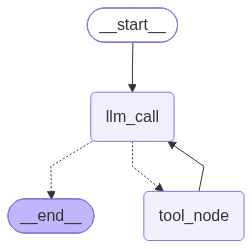

In [14]:
agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Let's test it!

In [11]:
prompt = "What can you tell me about latest trends in data centers?"

result = await agent.ainvoke({"messages": [HumanMessage(content=prompt)]})
for m in result["messages"]:
    m.pretty_print()

   -> Investment_Support_Agent
================================ Human Message =================================

What can you tell me about latest trends in data centers?
================================== Ai Message ==================================
Tool Calls:
  Investment_Support_Agent (call_pE31Uoelp2zCJI5EpcNwNt99)
 Call ID: call_pE31Uoelp2zCJI5EpcNwNt99
  Args:
    query: What are the latest trends in data centers?
================================= Tool Message =================================

[{'type': 'text', 'text': 'Based on recent information regarding major players in the data center industry, such as Equinix, here are some of the key trends currently shaping the sector:\n\n*   **Geographic Expansion into Emerging Markets:** Major data center providers are actively expanding their global footprint. For example, there has been significant movement toward establishing new facilities in emerging technological hubs in Southeast Asia, such as Kuala Lumpur, to support growing 

A question that needs both sides: the calculation runs locally, the graph question goes to Aura.
Neither side needs to know about the other.

---

## Summary

In this notebook, we connected a hosted Neo4j Aura Agent to LangGraph as a sub-agent:

1. **Machine-to-machine authentication** - client credentials from the Aura Agent & MCP tab exchanged for a bearer token at the gateway endpoint, with no browser step
2. **Token caching** - the endpoint allows 15 requests per hour per client ID, so each token is held for its full lifetime
3. **MCP connection** - `MultiServerMCPClient` turns the remote agent's tools into tools LangGraph can bind
4. **Delegation inside a node** - `tool_node` invokes an entire hosted agent, which plans and queries the graph on its own before replying

Because the agent's ontology, tools, and instructions live in Aura, graph logic stays with the graph
and changes in the Console take effect without a code change here. LangGraph keeps control of the
surrounding flow, which is where you'd add validation, approval gates, or additional sub-agents.

> **Token expiry.** MCP tools capture their headers when the client is created, so the token doesn't
> refresh itself. Call `mcp_client()` again when it expires and rebind the tools, or front the
> endpoint with a proxy that injects a current token per request.

### Resources

- [Aura Agent documentation](https://neo4j.com/docs/aura/aura-agent/) - configuration, external access, both authorization flows
- [Aura Agent getting started](https://neo4j.com/developer/genai-ecosystem/aura-agent-getting-started/) - building an agent from scratch